# FatigueSet — Procesado de Datos Completo
### 12 participantes × 3 sesiones × 3 fases de medición

Dataset multimodal para el estudio de fatiga física y mental mediante señales fisiológicas y tareas cognitivas.

**Protocolo por sesión:** S1 (baseline) → M1 (VAS+CRT+Nback) → S2 (ejercicio físico) → M2 (VAS+CRT+Nback) → S3 (task switching ~15min) → M3 (VAS+CRT+Nback)

**Sensores:** Zephyr BioHarness (ECG/HR/HRV/BR) · Empatica E4 (EDA/BVP/Temp) · Muse EEG (α/β/δ/γ/θ) · Nokia eSense (PPG auricular)


In [1]:
# ============================================================
# CELDA 1 — Importaciones y Configuración
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'fatigueset').exists()), Path.cwd())

# Ruta base del dataset (todos los participantes)
BASE_PATH = PROJECT_ROOT / 'fatigueset'

PARTICIPANTES = [f'{i:02d}' for i in range(1, 13)]  # '01' ... '12'
SESIONES      = ['01', '02', '03']

# Mapeo de measurementNumber → fase del protocolo
FASES_MEDICION = {
    0: 'M1_baseline',
    1: 'M2_post_ejercicio',
    2: 'M3_post_fatiga_mental'
}

print("✓ Librerías importadas")
print(f"✓ Participantes: {PARTICIPANTES}")
print(f"✓ Sesiones por participante: {SESIONES}")

✓ Librerías importadas
✓ Participantes: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
✓ Sesiones por participante: ['01', '02', '03']


In [2]:
# ============================================================
# CELDA 2 — Leer metadata.csv para el mapeo real de intensidades
# ============================================================
metadata_path = BASE_PATH / 'metadata.csv'
df_metadata = pd.read_csv(metadata_path)
print("Columnas metadata:", list(df_metadata.columns))
display(df_metadata.head(12))

Columnas metadata: ['participant_id', 'low_session', 'medium_session', 'high_session']


,participant_id,low_session,medium_session,high_session
0,1,1,2,3
1,2,1,3,2
2,3,2,3,1
3,4,3,2,1
4,5,3,1,2
5,6,2,1,3
6,7,1,2,3
7,8,1,3,2
8,9,2,3,1
9,10,3,2,1


In [3]:
# ============================================================
# CELDA 3 — Construir mapeo participante × sesión → intensidad
# ============================================================
# metadata.csv tiene columnas: participant_id, low_session, medium_session, high_session
# Cada columna indica QUÉ número de sesión (01/02/03) corresponde a esa intensidad.
# Ej: P02 → low_session=01, medium_session=03, high_session=02
#     → P02/sesión01=low, P02/sesión02=high, P02/sesión03=medium

INTENSIDAD_MAP = {}

for _, row in df_metadata.iterrows():
    pid = f"{int(row['participant_id']):02d}"
    # Invertir: de "intensidad→sesión" a "sesión→intensidad"
    mapa_sesion = {}
    mapa_sesion[f"{int(row['low_session']):02d}"]    = 'low'
    mapa_sesion[f"{int(row['medium_session']):02d}"] = 'medium'
    mapa_sesion[f"{int(row['high_session']):02d}"]   = 'high'
    INTENSIDAD_MAP[pid] = mapa_sesion

print("✓ Mapa de intensidades construido para", len(INTENSIDAD_MAP), "participantes")
print("\nEjemplos:")
for pid in ['01', '02', '08']:
    print(f"  P{pid}: {INTENSIDAD_MAP.get(pid)}")

# Verificar que todos los participantes tienen las 3 sesiones mapeadas
for pid, mapa in INTENSIDAD_MAP.items():
    intensidades = set(mapa.values())
    assert intensidades == {'low', 'medium', 'high'}, f"P{pid}: mapeo incompleto → {mapa}"
print("\n✓ Verificación OK — todos los participantes tienen low/medium/high correctamente asignados")


✓ Mapa de intensidades construido para 12 participantes

Ejemplos:
  P01: {'01': 'low', '02': 'medium', '03': 'high'}
  P02: {'01': 'low', '03': 'medium', '02': 'high'}
  P08: {'01': 'low', '03': 'medium', '02': 'high'}

✓ Verificación OK — todos los participantes tienen low/medium/high correctamente asignados


In [4]:
# ============================================================
# CELDA 4 — Funciones de carga genéricas (participante + sesión)
# ============================================================

def cargar_csv(participante, sesion, archivo):
    """Carga un CSV de fatigueset/<participante>/<sesion>/<archivo>"""
    ruta = BASE_PATH / participante / sesion / archivo
    if ruta.exists():
        df = pd.read_csv(ruta)
        df['participante'] = participante
        df['sesion']       = sesion
        intensidad = INTENSIDAD_MAP.get(participante, {}).get(sesion, 'unknown')
        df['intensidad']   = intensidad
        df['intensidad_num'] = {'low': 1, 'medium': 2, 'high': 3}.get(intensidad, 0)
        return df
    return None


def cargar_todos(archivo):
    """Carga un tipo de archivo de todos los participantes y sesiones."""
    dfs = []
    faltantes = []
    for pid in PARTICIPANTES:
        for ses in SESIONES:
            df = cargar_csv(pid, ses, archivo)
            if df is not None:
                dfs.append(df)
            else:
                faltantes.append(f"P{pid}/S{ses}")
    if faltantes:
        print(f"  ⚠️ No encontrado ({len(faltantes)}): {faltantes[:5]}{'...' if len(faltantes)>5 else ''}")
    return pd.concat(dfs, ignore_index=True) if dfs else None


def convertir_timestamp(df, col='timestamp'):
    if col in df.columns:
        df = df.copy()
        df['datetime'] = pd.to_datetime(df[col], unit='ms')
    return df


print("✓ Funciones de carga definidas")

✓ Funciones de carga definidas


In [5]:
# ============================================================
# CELDA 5 — Explorar estructura de archivos por sesión
# ============================================================
print("="*60)
print("ESTRUCTURA DEL DATASET")
print("="*60)

sesion_ejemplo = BASE_PATH / '01' / '01'
if sesion_ejemplo.exists():
    archivos = sorted([f.name for f in sesion_ejemplo.glob('*.csv')])
    print(f"\n📁 Archivos por sesión ({len(archivos)} total):")
    
    categorias = {
        'Chest (Zephyr)':     [a for a in archivos if a.startswith('chest_') or a.startswith('zephyr_')],
        'Wrist (Empatica E4)':[a for a in archivos if a.startswith('wrist_')],
        'Forehead (Muse)':    [a for a in archivos if a.startswith('forehead_') or a.startswith('muse_')],
        'Ear (eSense)':       [a for a in archivos if a.startswith('ear_')],
        'Experimental':       [a for a in archivos if a.startswith('exp_')],
    }
    for cat, listaA in categorias.items():
        if listaA:
            print(f"\n  📊 {cat}:")
            for a in listaA:
                print(f"     - {a}")

ESTRUCTURA DEL DATASET

📁 Archivos por sesión (39 total):

  📊 Chest (Zephyr):
     - chest_bb_interval.csv
     - chest_physiology_summary.csv
     - chest_raw_acc.csv
     - chest_raw_breathing.csv
     - chest_raw_ecg.csv
     - chest_rr_interval.csv
     - chest_sensor_summary.csv
     - zephyr_activity_summary.csv
     - zephyr_device_status.csv

  📊 Wrist (Empatica E4):
     - wrist_acc.csv
     - wrist_bvp.csv
     - wrist_eda.csv
     - wrist_hr.csv
     - wrist_ibi.csv
     - wrist_skin_temperature.csv

  📊 Forehead (Muse):
     - forehead_acc.csv
     - forehead_eeg_alpha_abs.csv
     - forehead_eeg_beta_abs.csv
     - forehead_eeg_delta_abs.csv
     - forehead_eeg_gamma_abs.csv
     - forehead_eeg_raw.csv
     - forehead_eeg_theta_abs.csv
     - forehead_gyro.csv
     - muse_blinks.csv
     - muse_device_battery.csv
     - muse_device_fit.csv
     - muse_device_touch.csv
     - muse_jaw_clenches.csv

  📊 Ear (eSense):
     - ear_acc_left.csv
     - ear_acc_right.csv
     - e

DATOS DE FATIGA — GROUND TRUTH (N=12 participantes)

✓ Total registros: 108
  Participantes con datos: 12
  Sesiones con datos:      36

📊 Scores globales (VAS 0-100):


physicalFatigueScore                                   \
                                     count   mean    std  min    25%    50%   
fase                                                                          
M1_baseline                           36.0  14.26  13.83  0.0   4.31  11.04   
M2_post_ejercicio                     36.0  31.15  21.60  0.0  14.58  26.60   
M3_post_fatiga_mental                 36.0  25.17  16.52  0.0  13.06  23.12   

                                    mentalFatigueScore                      \
                         75%    max              count   mean    std   min   
fase                                                                         
M1_baseline            18.72  55.42               36.0  18.36  15.49  0.00   
M2_post_ejercicio      45.52  77.22               36.0  24.49  17.62  0.14   
M3_post_fatiga_mental  38.47  57.78               36.0  36.38  21.86  0.00   

                                                   
                         25%    50%    75%    max  
fase                                               
M1_baseline             5.90  16.39  26.15  67.78  
M2_post_ejercicio      10.59  23.40  36.81  62.50  
M3_post_fatiga_mental  21.35  32.99  49.72  77.22

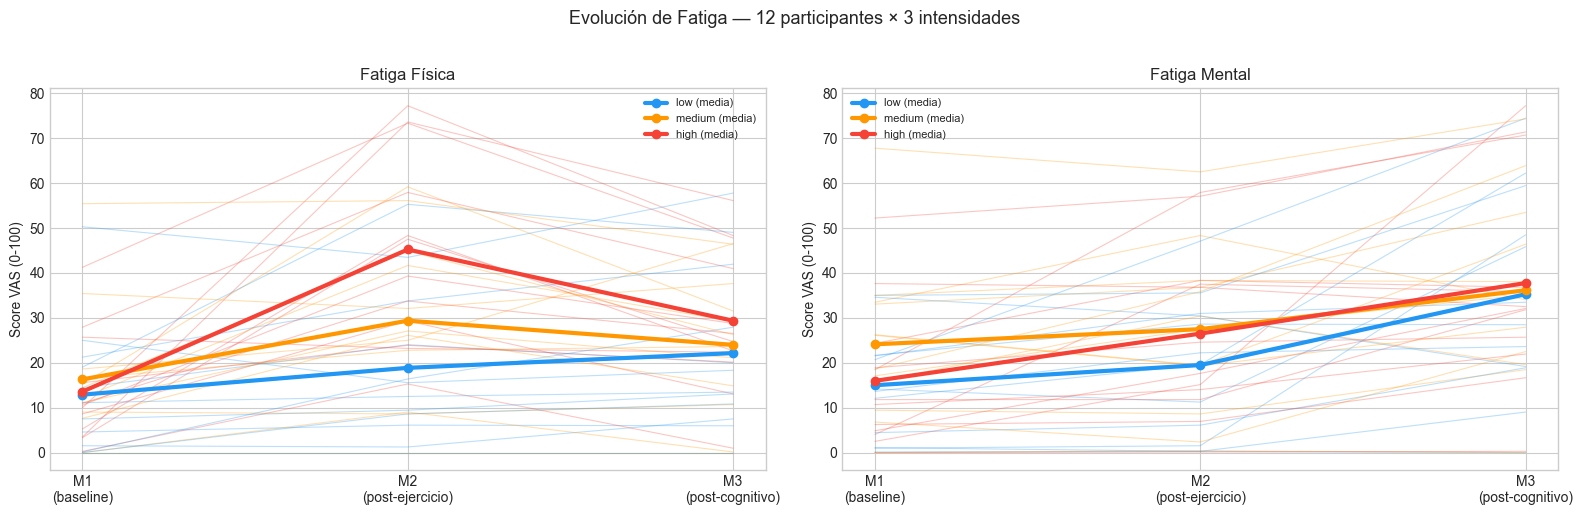

In [6]:
# ============================================================
# CELDA 6 — Cargar y validar Ground Truth (exp_fatigue.csv)
# ============================================================
print("="*60)
print("DATOS DE FATIGA — GROUND TRUTH (N=12 participantes)")
print("="*60)

df_fatiga = cargar_todos('exp_fatigue.csv')

if df_fatiga is not None:
    df_fatiga['fase'] = df_fatiga['measurementNumber'].map(FASES_MEDICION)

    print(f"\n✓ Total registros: {len(df_fatiga)}")
    print(f"  Participantes con datos: {df_fatiga['participante'].nunique()}")
    print(f"  Sesiones con datos:      {len(df_fatiga.groupby(['participante','sesion']))}")

    print("\n📊 Scores globales (VAS 0-100):")
    display(df_fatiga.groupby('fase')[['physicalFatigueScore','mentalFatigueScore']].describe().round(2))

    # --- Visualización por participante y fase ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    COLORES = {'low': '#2196F3', 'medium': '#FF9800', 'high': '#F44336'}

    for pid in PARTICIPANTES:
        for ses in SESIONES:
            df_s = df_fatiga[
                (df_fatiga['participante'] == pid) &
                (df_fatiga['sesion'] == ses)
            ].sort_values('measurementNumber')
            if df_s.empty:
                continue
            intensidad = df_s['intensidad'].iloc[0]
            color = COLORES.get(intensidad, 'gray')
            axes[0].plot(df_s['measurementNumber'], df_s['physicalFatigueScore'],
                         alpha=0.3, color=color, linewidth=0.8)
            axes[1].plot(df_s['measurementNumber'], df_s['mentalFatigueScore'],
                         alpha=0.3, color=color, linewidth=0.8)

    # Medias por intensidad
    for intensidad, color in COLORES.items():
        df_i = df_fatiga[df_fatiga['intensidad'] == intensidad].groupby('measurementNumber')
        media_f = df_i['physicalFatigueScore'].mean()
        media_m = df_i['mentalFatigueScore'].mean()
        axes[0].plot(media_f.index, media_f.values, color=color, linewidth=3,
                     marker='o', label=f'{intensidad} (media)')
        axes[1].plot(media_m.index, media_m.values, color=color, linewidth=3,
                     marker='o', label=f'{intensidad} (media)')

    fases_labels = ['M1\n(baseline)', 'M2\n(post-ejercicio)', 'M3\n(post-cognitivo)']
    for ax, titulo in zip(axes, ['Fatiga Física', 'Fatiga Mental']):
        ax.set_title(titulo)
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(fases_labels)
        ax.set_ylabel('Score VAS (0-100)')
        ax.legend(fontsize=8)

    plt.suptitle('Evolución de Fatiga — 12 participantes × 3 intensidades', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

✓ Fatigabilidad calculada: 36 sesiones de 12 participantes


,delta_fisica_ejercicio,delta_mental_ejercicio,delta_fisica_cognitivo,delta_mental_cognitivo,delta_fisica_total,delta_mental_total
intensidad,,,,,,
high,31.64,10.52,-15.86,11.25,15.79,21.77
low,5.96,4.49,3.29,15.76,9.25,20.25
medium,13.07,3.38,-5.38,8.66,7.69,12.04


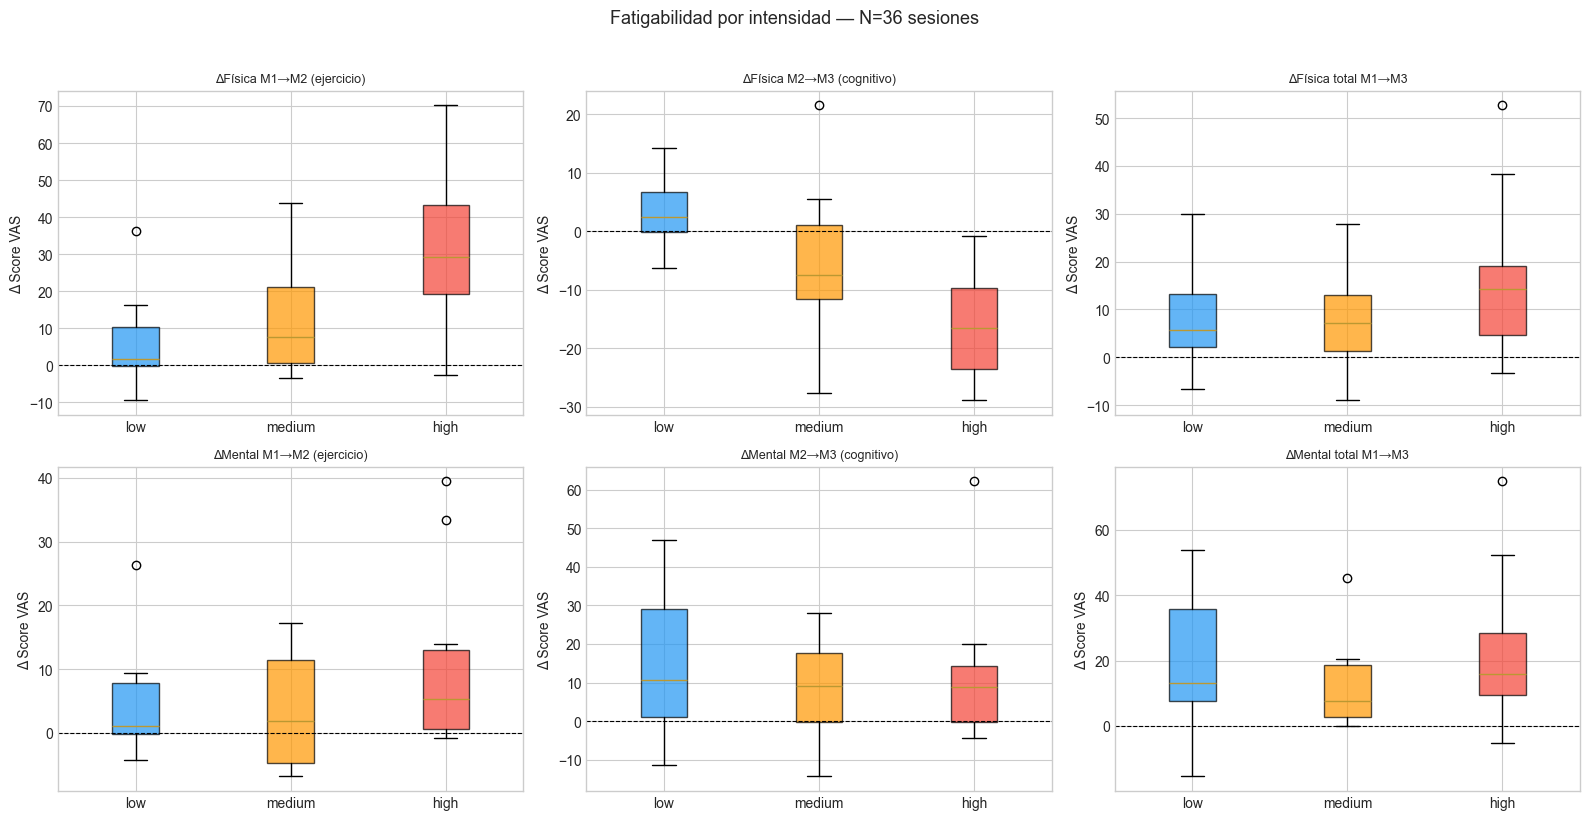

In [7]:
# ============================================================
# CELDA 7 — Calcular Fatigabilidad (N=36 sesiones)
# ============================================================

def calcular_fatigabilidad(df_fatiga):
    """Calcula deltas entre fases para cada (participante, sesión)."""
    resultados = []
    for pid in PARTICIPANTES:
        for ses in SESIONES:
            df_s = df_fatiga[
                (df_fatiga['participante'] == pid) &
                (df_fatiga['sesion'] == ses)
            ].sort_values('measurementNumber')
            m = {row['measurementNumber']: row for _, row in df_s.iterrows()}
            if 0 in m and 1 in m and 2 in m:
                intensidad = INTENSIDAD_MAP.get(pid, {}).get(ses, 'unknown')
                resultados.append({
                    'participante': pid,
                    'sesion': ses,
                    'intensidad': intensidad,
                    'intensidad_num': {'low':1,'medium':2,'high':3}.get(intensidad, 0),
                    # Efecto del ejercicio (M1→M2)
                    'delta_fisica_ejercicio': m[1]['physicalFatigueScore'] - m[0]['physicalFatigueScore'],
                    'delta_mental_ejercicio': m[1]['mentalFatigueScore']   - m[0]['mentalFatigueScore'],
                    # Efecto cognitivo (M2→M3)
                    'delta_fisica_cognitivo': m[2]['physicalFatigueScore'] - m[1]['physicalFatigueScore'],
                    'delta_mental_cognitivo': m[2]['mentalFatigueScore']   - m[1]['mentalFatigueScore'],
                    # Efecto total (M1→M3)
                    'delta_fisica_total':     m[2]['physicalFatigueScore'] - m[0]['physicalFatigueScore'],
                    'delta_mental_total':     m[2]['mentalFatigueScore']   - m[0]['mentalFatigueScore'],
                    # Scores absolutos
                    'fisica_M1': m[0]['physicalFatigueScore'],
                    'fisica_M2': m[1]['physicalFatigueScore'],
                    'fisica_M3': m[2]['physicalFatigueScore'],
                    'mental_M1': m[0]['mentalFatigueScore'],
                    'mental_M2': m[1]['mentalFatigueScore'],
                    'mental_M3': m[2]['mentalFatigueScore'],
                })
    return pd.DataFrame(resultados)


df_fatigabilidad = calcular_fatigabilidad(df_fatiga)
print(f"✓ Fatigabilidad calculada: {len(df_fatigabilidad)} sesiones de {df_fatigabilidad['participante'].nunique()} participantes")
display(df_fatigabilidad.groupby('intensidad')[
    ['delta_fisica_ejercicio','delta_mental_ejercicio',
     'delta_fisica_cognitivo','delta_mental_cognitivo',
     'delta_fisica_total','delta_mental_total']
].mean().round(2))

# Boxplots de fatigabilidad por intensidad
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
COLORES = {'low': '#2196F3', 'medium': '#FF9800', 'high': '#F44336'}

metricas = [
    ('delta_fisica_ejercicio', 'ΔFísica M1→M2 (ejercicio)'),
    ('delta_fisica_cognitivo', 'ΔFísica M2→M3 (cognitivo)'),
    ('delta_fisica_total',     'ΔFísica total M1→M3'),
    ('delta_mental_ejercicio', 'ΔMental M1→M2 (ejercicio)'),
    ('delta_mental_cognitivo', 'ΔMental M2→M3 (cognitivo)'),
    ('delta_mental_total',     'ΔMental total M1→M3'),
]

for ax, (col, titulo) in zip(axes.flatten(), metricas):
    datos = [df_fatigabilidad[df_fatigabilidad['intensidad'] == i][col].dropna()
             for i in ['low', 'medium', 'high']]
    bp = ax.boxplot(datos, patch_artist=True, labels=['low', 'medium', 'high'])
    for patch, color in zip(bp['boxes'], COLORES.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(titulo, fontsize=9)
    ax.set_ylabel('Δ Score VAS')

plt.suptitle('Fatigabilidad por intensidad — N=36 sesiones', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELDA 8 — Cargar Marcadores de Experimento
# ============================================================
print("="*60)
print("MARCADORES DE EXPERIMENTO")
print("="*60)

df_markers = cargar_todos('exp_markers.csv')

if df_markers is not None:
    df_markers = convertir_timestamp(df_markers, 'utcTime')
    print(f"\n✓ Total eventos: {len(df_markers)}")
    print(f"  Participantes: {df_markers['participante'].nunique()}")
    print("\n📊 Tipos de eventos (todos los participantes):")
    print(df_markers['eventMarker'].value_counts().to_string())

MARCADORES DE EXPERIMENTO

✓ Total eventos: 612
  Participantes: 12

📊 Tipos de eventos (todos los participantes):
eventMarker
submit_survey       108
start_crt           108
start_nback         108
start_experiment     36
start_baseline       36
end_baseline         36
start_activity       36
end_activity         36
start_fatigue        36
end_fatigue          36
end_session          36


DATOS FISIOLÓGICOS — PECHO (ZEPHYR)



✓ Total registros: 45874
  Participantes: 12


hr                                                     br  \
              count   mean    std   min   25%   50%    75%    max    count   
intensidad                                                                   
high        15461.0  98.32  30.13  52.0  75.0  91.0  116.0  211.0  15461.0   
low         14332.0  79.32  17.13  48.0  69.0  77.0   87.0  163.0  14332.0   
medium      16081.0  85.19  20.66  56.0  72.0  79.0   91.0  172.0  16081.0   

                                                           hrv                \
             mean   std   min   25%   50%   75%   max    count   mean    std   
intensidad                                                                     
high        22.30  5.81  10.0  19.0  21.0  25.0  45.0  14008.0  59.87  42.27   
low         19.79  4.92   8.0  16.0  20.0  22.0  39.0  13702.0  73.03  36.74   
medium      20.07  5.42   4.0  17.0  20.0  22.0  43.0  15709.0  71.33  35.96   

                                          posture                        \
            min   25%   50%   75%    max    count    mean    std    min   
intensidad                                                                
high        4.0  26.0  54.0  82.0  211.0  15461.0 -136.78  80.57 -179.0   
low         5.0  46.0  64.0  95.0  201.0  14332.0 -145.49  62.15 -179.0   
medium      5.0  46.0  62.0  91.0  208.0  16081.0 -158.06  46.91 -179.0   

                                        
              25%    50%    75%    max  
intensidad                              
high       -173.0 -167.0 -155.0  180.0  
low        -172.0 -167.0 -157.0  180.0  
medium     -173.0 -166.0 -157.0  180.0


⚠️ Registros no confiables (global):
  is_hr_unreliable: 2841 (6.19%)
  is_br_unreliable: 300 (0.65%)
  is_hrv_unreliable: 0 (0.00%)


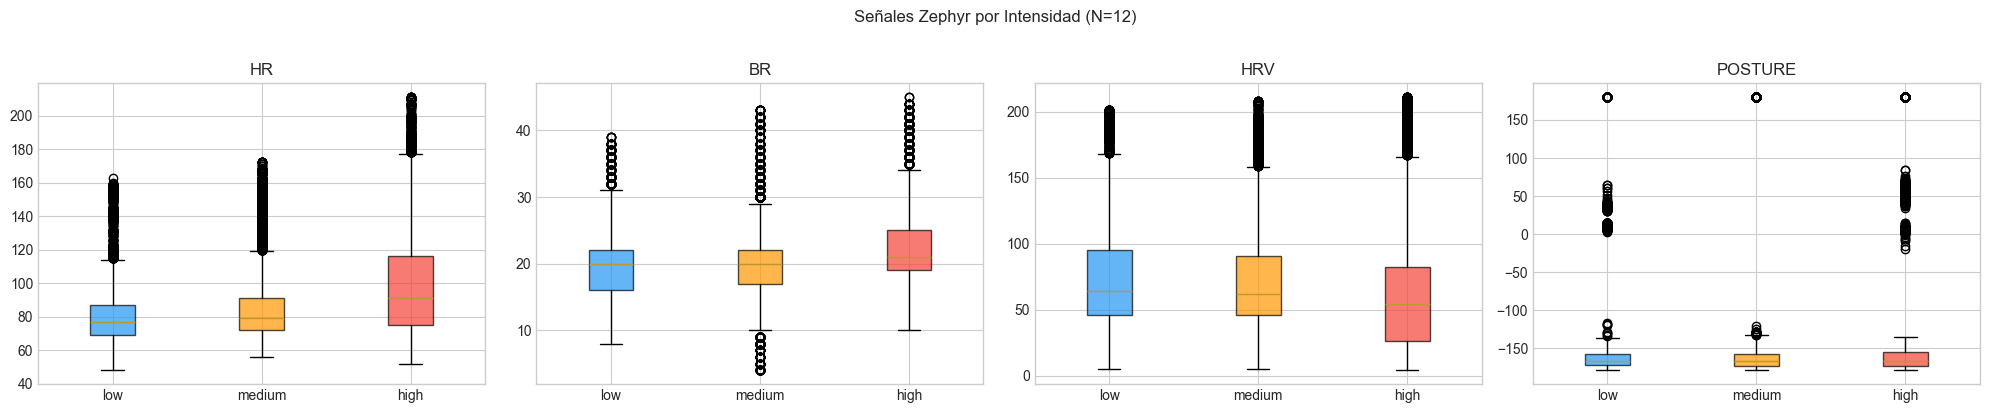

In [9]:
# ============================================================
# CELDA 9 — Procesar Datos Fisiológicos del Pecho (Zephyr)
# ============================================================
print("="*60)
print("DATOS FISIOLÓGICOS — PECHO (ZEPHYR)")
print("="*60)

df_chest = cargar_todos('chest_physiology_summary.csv')

if df_chest is not None:
    df_chest = convertir_timestamp(df_chest)
    print(f"\n✓ Total registros: {len(df_chest)}")
    print(f"  Participantes: {df_chest['participante'].nunique()}")

    # Estadísticas por intensidad
    cols_fisio = [c for c in ['hr','br','hrv','posture'] if c in df_chest.columns]
    display(df_chest.groupby('intensidad')[cols_fisio].describe().round(2))

    # Verificar datos no confiables
    print("\n⚠️ Registros no confiables (global):")
    for col in ['is_hr_unreliable','is_br_unreliable','is_hrv_unreliable']:
        if col in df_chest.columns:
            n = (df_chest[col] == 1).sum()
            pct = n / len(df_chest) * 100
            print(f"  {col}: {n} ({pct:.2f}%)")

    # Boxplot HR por intensidad
    fig, axes = plt.subplots(1, len(cols_fisio), figsize=(5*len(cols_fisio), 4))
    if len(cols_fisio) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_fisio):
        datos = [df_chest[df_chest['intensidad'] == i][col].dropna()
                 for i in ['low','medium','high']]
        bp = ax.boxplot(datos, patch_artist=True, labels=['low','medium','high'])
        for patch, c in zip(bp['boxes'], ['#2196F3','#FF9800','#F44336']):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_title(col.upper())
    plt.suptitle('Señales Zephyr por Intensidad (N=12)', y=1.02)
    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# CELDA 10 — Procesar Datos de Muñeca (Empatica E4)
# ============================================================
print("="*60)
print("DATOS FISIOLÓGICOS — MUÑECA (EMPATICA E4)")
print("="*60)

df_wrist_hr   = cargar_todos('wrist_hr.csv')
df_wrist_eda  = cargar_todos('wrist_eda.csv')
df_wrist_temp = cargar_todos('wrist_skin_temperature.csv')
df_wrist_bvp  = cargar_todos('wrist_bvp.csv')

for nombre, df in [('HR', df_wrist_hr), ('EDA', df_wrist_eda),
                   ('Temperatura', df_wrist_temp), ('BVP', df_wrist_bvp)]:
    if df is not None:
        col_val = [c for c in df.columns if c not in
                   ['timestamp','sesion','participante','intensidad','intensidad_num','datetime']][0]
        print(f"\n{nombre} ({col_val}):")
        print(f"  Registros: {len(df)} | Participantes: {df['participante'].nunique()}")
        print(f"  Global: media={df[col_val].mean():.3f}, std={df[col_val].std():.3f}")
        display(df.groupby('intensidad')[col_val].describe().round(3))

DATOS FISIOLÓGICOS — MUÑECA (EMPATICA E4)



HR (hr):
  Registros: 43608 | Participantes: 12
  Global: media=85.042, std=20.581


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,14476.0,89.507,22.527,54.35,72.928,82.52,103.79,156.13
low,13048.0,80.111,17.575,52.78,69.580,76.45,85.87,156.63
medium,16084.0,85.024,20.088,60.05,72.180,78.10,89.53,158.33



EDA (eda):
  Registros: 174423 | Participantes: 12
  Global: media=1.328, std=2.137


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,57885.0,1.885,2.627,0.0,0.295,0.568,2.502,14.302
low,52212.0,0.758,1.130,0.0,0.138,0.316,0.819,6.766
medium,64326.0,1.288,2.143,0.0,0.179,0.388,1.071,14.489


...

,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,57623.0,33.913,1.349,28.83,33.21,33.97,34.59,36.77
low,52212.0,33.210,2.453,25.07,32.65,33.71,34.66,37.05
medium,64326.0,33.252,2.233,28.33,32.50,34.18,34.59,36.95



BVP (bvp):


  Registros: 2790818 | Participantes: 12


  Global: media=-0.004, std=56.148


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,926225.0,-0.008,59.891,-1156.99,-13.98,1.08,14.63,1371.58
low,835471.0,-0.013,52.701,-1214.41,-13.00,1.56,13.84,1611.91
medium,1029122.0,0.008,55.373,-870.54,-14.28,1.30,14.95,1063.45


DATOS EEG — FRENTE (MUSE)



✓ ALPHA: 413176 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134555.0,0.5822,0.2866,-0.1601,0.3879,0.5512,0.7464,2.5169
low,127266.0,0.5446,0.2596,-0.1669,0.3796,0.5286,0.7116,1.4382
medium,151355.0,-inf,NaN,-inf,0.4049,0.5529,0.7323,2.7972



✓ BETA: 413130 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134552.0,0.4158,0.2396,-0.2031,0.2457,0.3865,0.5768,1.9357
low,127216.0,0.3650,0.1830,-0.0626,0.2495,0.3530,0.4577,1.1179
medium,151362.0,-inf,NaN,-inf,0.2812,0.3941,0.5500,2.1963


...

,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134526.0,0.6334,0.4391,-0.5886,0.3114,0.6005,0.8953,3.4106
low,127192.0,0.5562,0.3929,-0.6138,0.2525,0.5538,0.8485,1.5858
medium,151340.0,-inf,NaN,-inf,0.2811,0.5474,0.8525,3.6396



✓ GAMMA: 412833 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134508.0,0.1255,0.2880,-0.6461,-0.0778,0.0738,0.3126,1.4260
low,127165.0,0.1377,0.1643,-0.4068,0.0143,0.1226,0.2437,0.9033
medium,151160.0,-inf,NaN,-inf,0.0060,0.1322,0.3375,1.6037



✓ THETA: 413029 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134554.0,0.441,0.3562,-0.5056,0.1818,0.3914,0.6629,2.3934
low,127144.0,0.444,0.3572,-0.5045,0.1791,0.3911,0.6922,1.4638
medium,151331.0,-inf,NaN,-inf,0.1874,0.3723,0.6175,2.6882


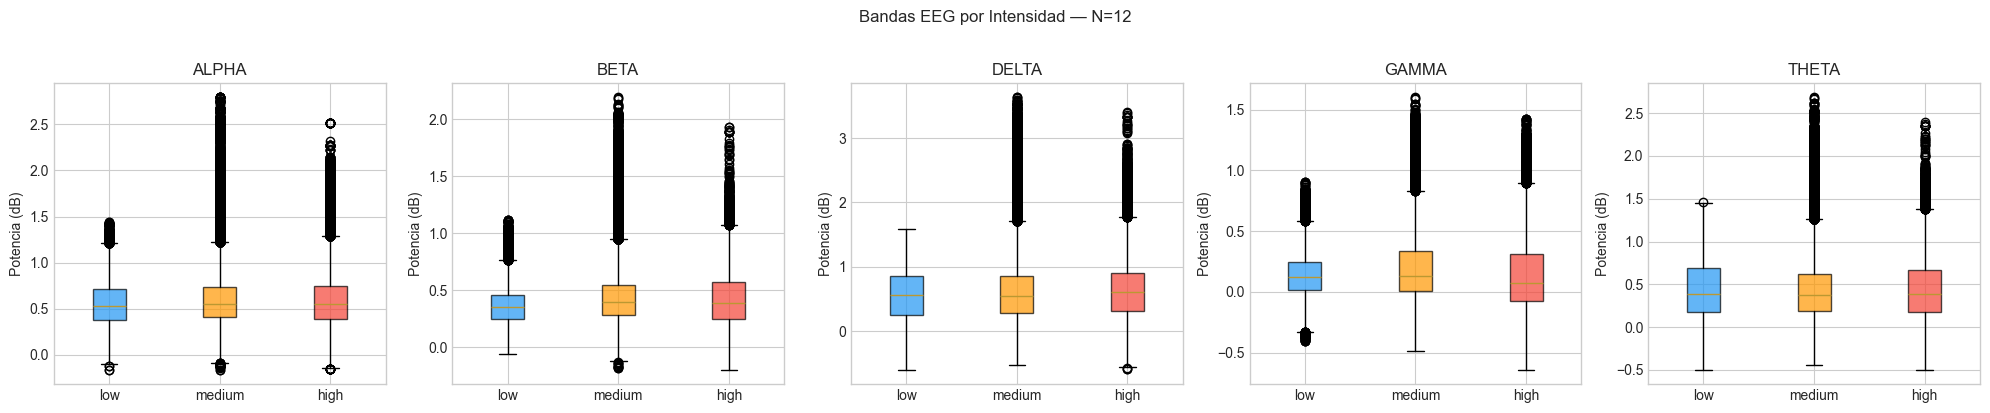

In [11]:
# ============================================================
# CELDA 11 — Procesar Datos EEG (Muse)
# ============================================================
print("="*60)
print("DATOS EEG — FRENTE (MUSE)")
print("="*60)

bandas_eeg = ['alpha', 'beta', 'delta', 'gamma', 'theta']
eeg_data = {}
CANALES  = ['TP9', 'AF7', 'AF8', 'TP10']

for banda in bandas_eeg:
    df = cargar_todos(f'forehead_eeg_{banda}_abs.csv')
    if df is not None:
        eeg_data[banda] = df
        canales_ok = [c for c in CANALES if c in df.columns]
        print(f"\n✓ {banda.upper()}: {len(df)} registros | canales: {canales_ok}")
        df['promedio_canales'] = df[canales_ok].mean(axis=1)
        display(df.groupby('intensidad')['promedio_canales'].describe().round(4))

# Visualización: potencia media por banda e intensidad
if eeg_data:
    fig, axes = plt.subplots(1, len(eeg_data), figsize=(4*len(eeg_data), 4))
    for ax, banda in zip(axes, eeg_data.keys()):
        df = eeg_data[banda].copy()
        canales_ok = [c for c in CANALES if c in df.columns]
        df['prom'] = df[canales_ok].mean(axis=1)
        datos = [df[df['intensidad'] == i]['prom'].dropna()
                 for i in ['low','medium','high']]
        bp = ax.boxplot(datos, patch_artist=True, labels=['low','medium','high'])
        for patch, c in zip(bp['boxes'], ['#2196F3','#FF9800','#F44336']):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_title(banda.upper())
        ax.set_ylabel('Potencia (dB)')
    plt.suptitle('Bandas EEG por Intensidad — N=12', y=1.02)
    plt.tight_layout()
    plt.show()

In [12]:
# ============================================================
# CELDA 12 — Procesar Datos de Oído (eSense)
# ============================================================
print("="*60)
print("DATOS — OÍDO (eSense PPG)")
print("="*60)

df_ear_left  = cargar_todos('ear_ppg_left.csv')
df_ear_right = cargar_todos('ear_ppg_right.csv')

for nombre, df in [('PPG Izquierdo', df_ear_left), ('PPG Derecho', df_ear_right)]:
    if df is not None:
        print(f"\n{nombre}: {len(df)} registros | Participantes: {df['participante'].nunique()}")
        cols_datos = [c for c in ['green','ir','red'] if c in df.columns]
        if cols_datos:
            display(df.groupby('intensidad')[cols_datos].describe().round(2))

DATOS — OÍDO (eSense PPG)



PPG Izquierdo: 3932967 registros | Participantes: 12


green                                                          \
                count      mean       std      min      25%      50%      75%   
intensidad                                                                      
high        1194703.0  55604.31  27173.10    875.0  36279.0  45473.0  84582.0   
low         1211537.0  55876.03  28625.12   9013.0  31083.0  51991.0  86462.0   
medium      1526727.0  61850.08  25744.47  26479.0  42553.0  55506.0  73864.0   

                             ir                                          \
                 max      count       mean       std      min       25%   
intensidad                                                                
high        128791.0  1194703.0  286802.47  41702.20   1406.0  276494.0   
low         110839.0  1211537.0  299293.47  32617.35  57805.0  286205.0   
medium      122774.0  1526727.0  285257.58  49529.71  47381.0  254281.0   

                                                red                       \
                 50%       75%       max      count       mean       std   
intensidad                                                                 
high        285222.0  323137.5  387717.0  1194703.0  291486.45  92944.33   
low         307068.0  323233.0  354027.0  1211537.0  306007.99  85324.97   
medium      284200.0  330691.0  382741.0  1526727.0  297395.49  83847.56   

                                                             
                min       25%       50%       75%       max  
intensidad                                                   
high         1881.0  207385.0  296935.0  372984.0  479585.0  
low         57798.0  210010.0  317305.0  394190.0  431927.0  
medium      57838.0  202807.0  304582.0  367269.5  430256.0


PPG Derecho: 3933102 registros | Participantes: 12


green                                                         \
                count      mean       std     min      25%      50%      75%   
intensidad                                                                     
high        1194830.0  37969.44  20161.67  1955.0  23145.0  32506.0  47519.0   
low         1211378.0  39400.01  12382.70  2448.0  32642.0  36526.0  41989.0   
medium      1526894.0  40728.84  17677.26  4418.0  25465.0  38293.0  51073.0   

                             ir                                         \
                 max      count       mean       std     min       25%   
intensidad                                                               
high        109187.0  1194830.0  208530.08  48410.65  2435.0  174160.0   
low         118510.0  1211378.0  220211.27  38931.90  3228.0  197598.0   
medium      144116.0  1526894.0  227418.99  40262.83  6176.0  196909.0   

                                                 red                       \
                 50%        75%       max      count       mean       std   
intensidad                                                                  
high        208322.0  233457.75  338392.0  1194830.0  207404.23  85296.76   
low         217186.0  257557.00  323388.0  1211378.0  217358.38  55519.81   
medium      229579.5  256974.00  355920.0  1526894.0  231277.11  74776.11   

                                                              
                min        25%       50%       75%       max  
intensidad                                                    
high         4634.0  137075.00  198043.0  269274.0  447258.0  
low          5859.0  167389.00  210874.0  265692.0  498447.0  
medium      12020.0  152075.25  217231.0  278021.0  461417.0

In [13]:
# ============================================================
# CELDA 13 — Procesar Tareas Cognitivas
# ============================================================
print("="*60)
print("TAREAS COGNITIVAS")
print("="*60)

def _numeric_mean(df, col):
    return pd.to_numeric(df[col], errors='coerce').mean()

# ---- N-Back ----
df_nback = cargar_todos('exp_nback.csv')

if df_nback is not None:
    if 'measurementNumber' in df_nback.columns:
        df_nback['fase'] = df_nback['measurementNumber'].map(FASES_MEDICION)

    print(f"\n📊 N-Back: {len(df_nback)} trials | {df_nback['participante'].nunique()} participantes")

    if 'isCorrectResponse' in df_nback.columns and 'fase' in df_nback.columns:
        resumen_nback = df_nback.groupby(['intensidad', 'fase']).agg(
            accuracy  = ('isCorrectResponse', lambda x: pd.to_numeric(x, errors='coerce').mean() * 100),
            n_trials  = ('isCorrectResponse', 'count')
        ).round(2)
        display(resumen_nback)

# ---- CRT ----
df_crt = cargar_todos('exp_crt.csv')

if df_crt is not None:
    if 'measurementNumber' in df_crt.columns:
        df_crt['fase'] = df_crt['measurementNumber'].map(FASES_MEDICION)

    print(f"\n📊 CRT: {len(df_crt)} trials | {df_crt['participante'].nunique()} participantes")

    rt_col  = next((c for c in df_crt.columns if 'time' in c.lower() and 'response' in c.lower()
                    and pd.to_numeric(df_crt[c], errors='coerce').notna().any()), None)
    acc_col = next((c for c in df_crt.columns
                    if 'correct' in c.lower()
                    and pd.to_numeric(df_crt[c], errors='coerce').notna().any()
                    and df_crt[c].dtype in [bool, np.bool_, np.int64, np.float64]), None)

    agg_dict = {}
    if rt_col:  agg_dict['rt_medio']  = (rt_col,  lambda x: pd.to_numeric(x, errors='coerce').mean())
    if acc_col: agg_dict['accuracy']  = (acc_col, lambda x: pd.to_numeric(x, errors='coerce').mean()*100)
    agg_dict['n_trials'] = (df_crt.columns[0], 'count')

    if 'fase' in df_crt.columns and agg_dict:
        display(df_crt.groupby(['intensidad','fase']).agg(**agg_dict).round(3))

# ---- Task Switch ----
df_task_switch = cargar_todos('exp_task_switch.csv')
if df_task_switch is not None:
    print(f"\n📊 Task Switch: {len(df_task_switch)} trials | {df_task_switch['participante'].nunique()} participantes")
    print("  (Se usa para INDUCIR fatiga mental en S3 — no es métrica de rendimiento M1/M2/M3)")

TAREAS COGNITIVAS

📊 N-Back: 2160 trials | 12 participantes



📊 CRT: 3888 trials | 12 participantes

📊 Task Switch: 7200 trials | 12 participantes
  (Se usa para INDUCIR fatiga mental en S3 — no es métrica de rendimiento M1/M2/M3)


In [14]:
# ============================================================
# CELDA 14 — Validación de Integridad
# ============================================================
print("="*60)
print("VALIDACIÓN DE INTEGRIDAD DE DATOS")
print("="*60)

archivos_validar = [
    ('chest_physiology_summary.csv', 'Chest Physiology'),
    ('chest_raw_ecg.csv',            'ECG Raw'),
    ('wrist_hr.csv',                 'Wrist HR'),
    ('wrist_eda.csv',                'Wrist EDA'),
    ('wrist_skin_temperature.csv',   'Wrist Temp'),
    ('forehead_eeg_alpha_abs.csv',   'EEG Alpha'),
    ('forehead_eeg_beta_abs.csv',    'EEG Beta'),
    ('ear_ppg_left.csv',             'Ear PPG Left'),
    ('exp_fatigue.csv',              'Fatigue Scores'),
    ('exp_nback.csv',                'N-Back Task'),
    ('exp_crt.csv',                  'CRT Task'),
]

resumen = []
for archivo, nombre in archivos_validar:
    for pid in PARTICIPANTES:
        for ses in SESIONES:
            df = cargar_csv(pid, ses, archivo)
            if df is not None:
                n_filas     = len(df)
                pct_nulos   = df.isnull().sum().sum() / (n_filas * len(df.columns)) * 100
                n_dupl      = df.duplicated().sum()
                resumen.append({
                    'Archivo':    nombre,
                    'Participante': pid,
                    'Sesión':     ses,
                    'Filas':      n_filas,
                    'Nulos (%)':  round(pct_nulos, 2),
                    'Duplicados': n_dupl,
                    'Estado':     '✓' if pct_nulos < 5 and n_dupl == 0 else '⚠️'
                })

df_val = pd.DataFrame(resumen)

# Resumen agregado por archivo
print("\n📊 Resumen por tipo de archivo:")
display(df_val.groupby('Archivo').agg(
    Sesiones_OK    = ('Estado', lambda x: (x=='✓').sum()),
    Sesiones_total = ('Estado', 'count'),
    Nulos_pct_max  = ('Nulos (%)', 'max'),
    Duplicados_max = ('Duplicados', 'max'),
).round(2))

# Detalle solo de los problemáticos
problemas = df_val[df_val['Estado'] == '⚠️']
if not problemas.empty:
    print(f"\n⚠️ Sesiones con problemas: {len(problemas)}")
    display(problemas)

VALIDACIÓN DE INTEGRIDAD DE DATOS



📊 Resumen por tipo de archivo:


,Sesiones_OK,Sesiones_total,Nulos_pct_max,Duplicados_max
Archivo,,,,
CRT Task,36,36,0.43,0
Chest Physiology,36,36,2.57,0
ECG Raw,36,36,0.00,0
EEG Alpha,21,36,0.00,782
EEG Beta,22,36,0.00,781
Ear PPG Left,36,36,0.00,0
Fatigue Scores,36,36,0.00,0
N-Back Task,0,36,19.74,0
Wrist EDA,36,36,0.00,0



⚠️ Sesiones con problemas: 65


,Archivo,Participante,Sesión,Filas,Nulos (%),Duplicados,Estado
189,EEG Alpha,04,01,0,NaN,0,⚠️
190,EEG Alpha,04,02,13585,0.00,140,⚠️
193,EEG Alpha,05,02,10668,0.00,17,⚠️
194,EEG Alpha,05,03,9579,0.00,1,⚠️
195,EEG Alpha,06,01,11295,0.00,150,⚠️
...,...,...,...,...,...,...,...
355,N-Back Task,11,02,60,18.21,0,⚠️
356,N-Back Task,11,03,60,18.46,0,⚠️
357,N-Back Task,12,01,60,19.74,0,⚠️
358,N-Back Task,12,02,60,18.46,0,⚠️


In [15]:
# ============================================================
# CELDA 15 — Dataset Agregado para ML (108 filas = 12×3×3)
# ============================================================
print("="*60)
print("DATASET AGREGADO PARA MACHINE LEARNING")
print("="*60)
print("Granularidad: 108 mediciones (12 participantes × 3 sesiones × 3 fases)")

def _buscar_col_num(df, patron):
    return [c for c in df.columns if patron in c.lower()
            and pd.to_numeric(df[c], errors='coerce').notna().any()]

datos_ml = []

for pid in PARTICIPANTES:
    for ses in SESIONES:
        intensidad     = INTENSIDAD_MAP.get(pid, {}).get(ses, 'unknown')
        intensidad_num = {'low':1,'medium':2,'high':3}.get(intensidad, 0)

        for fase_num, fase_nombre in FASES_MEDICION.items():
            fila = {
                'participante':   pid,
                'sesion':         ses,
                'intensidad':     intensidad,
                'intensidad_num': intensidad_num,
                'fase':           fase_nombre,
                'fase_num':       fase_num,
            }

            # Scores de fatiga
            if df_fatiga is not None:
                df_f = df_fatiga[
                    (df_fatiga['participante'] == pid) &
                    (df_fatiga['sesion'] == ses) &
                    (df_fatiga['measurementNumber'] == fase_num)
                ]
                if not df_f.empty:
                    fila['fatiga_fisica'] = df_f['physicalFatigueScore'].iloc[0]
                    fila['fatiga_mental'] = df_f['mentalFatigueScore'].iloc[0]

            # Señales Zephyr (tercio temporal como aproximación a fase)
            if df_chest is not None:
                df_c = df_chest[
                    (df_chest['participante'] == pid) &
                    (df_chest['sesion'] == ses)
                ].reset_index(drop=True)
                n = len(df_c)
                if n > 0:
                    s, e = int(fase_num*n/3), int((fase_num+1)*n/3)
                    seg = df_c.iloc[s:e]
                    for col in ['hr','br','hrv']:
                        if col in seg.columns:
                            fila[f'{col}_media'] = seg[col].mean()
                            fila[f'{col}_std']   = seg[col].std()

            # EDA
            if df_wrist_eda is not None:
                df_e = df_wrist_eda[
                    (df_wrist_eda['participante'] == pid) &
                    (df_wrist_eda['sesion'] == ses)
                ].reset_index(drop=True)
                n = len(df_e)
                if n > 0:
                    s, e = int(fase_num*n/3), int((fase_num+1)*n/3)
                    seg = df_e.iloc[s:e]
                    if 'eda' in seg.columns:
                        fila['eda_media'] = seg['eda'].mean()
                        fila['eda_std']   = seg['eda'].std()

            # EEG
            for banda in ['alpha', 'beta', 'theta']:
                if banda in eeg_data:
                    df_eeg = eeg_data[banda][
                        (eeg_data[banda]['participante'] == pid) &
                        (eeg_data[banda]['sesion'] == ses)
                    ].reset_index(drop=True)
                    n = len(df_eeg)
                    if n > 0:
                        s, e = int(fase_num*n/3), int((fase_num+1)*n/3)
                        seg = df_eeg.iloc[s:e]
                        canales_ok = [c for c in CANALES if c in seg.columns]
                        if canales_ok:
                            fila[f'eeg_{banda}_media'] = seg[canales_ok].mean().mean()

            # N-back por fase
            if df_nback is not None and 'fase' in df_nback.columns:
                df_n = df_nback[
                    (df_nback['participante'] == pid) &
                    (df_nback['sesion'] == ses) &
                    (df_nback['fase'] == fase_nombre)
                ]
                if not df_n.empty and 'isCorrectResponse' in df_n.columns:
                    fila['nback_accuracy'] = pd.to_numeric(
                        df_n['isCorrectResponse'], errors='coerce').mean() * 100
                    rt_col = _buscar_col_num(df_n, 'responsetime')
                    if rt_col:
                        fila['nback_rt'] = pd.to_numeric(df_n[rt_col[0]], errors='coerce').mean()

            # CRT por fase
            if df_crt is not None and 'fase' in df_crt.columns:
                df_c2 = df_crt[
                    (df_crt['participante'] == pid) &
                    (df_crt['sesion'] == ses) &
                    (df_crt['fase'] == fase_nombre)
                ]
                if not df_c2.empty:
                    rt_col = next(
                        (c for c in df_c2.columns if 'time' in c.lower() and 'response' in c.lower()
                         and pd.to_numeric(df_c2[c], errors='coerce').notna().any()), None)
                    if rt_col:
                        fila['crt_rt'] = pd.to_numeric(df_c2[rt_col], errors='coerce').mean()

            datos_ml.append(fila)

df_ml = pd.DataFrame(datos_ml)
print(f"\n✓ Dataset ML: {len(df_ml)} filas × {len(df_ml.columns)} columnas")
display(df_ml.describe().round(3))

# Guardar CSV
df_ml.to_csv('fatigueset_aggregated_features.csv', index=False)
print("\n✓ Guardado: fatigueset_aggregated_features.csv")

DATASET AGREGADO PARA MACHINE LEARNING
Granularidad: 108 mediciones (12 participantes × 3 sesiones × 3 fases)



✓ Dataset ML: 108 filas × 19 columnas


,intensidad_num,fase_num,fatiga_fisica,fatiga_mental,hr_media,hr_std,br_media,br_std,hrv_media,hrv_std,eda_media,eda_std,eeg_alpha_media,eeg_beta_media,eeg_theta_media
count,108.00,108.00,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,105.000,105.000,105.000
mean,2.00,1.00,23.529,26.411,87.875,11.357,20.806,2.794,69.464,19.737,1.273,0.474,-inf,-inf,-inf
std,0.82,0.82,18.809,19.819,20.157,8.072,4.498,1.590,31.155,14.958,1.789,0.885,NaN,NaN,NaN
min,1.00,0.00,0.000,0.000,58.907,2.002,11.682,0.529,11.276,0.430,0.076,0.003,-inf,-inf,-inf
25%,1.00,0.00,9.028,11.667,73.804,4.960,17.875,1.578,49.336,7.861,0.194,0.024,0.466,0.300,0.299
50%,2.00,1.00,20.069,23.056,81.871,9.430,20.328,2.396,64.569,15.014,0.477,0.096,0.541,0.383,0.412
75%,3.00,2.00,34.167,36.076,97.107,15.014,23.397,3.730,86.265,25.288,1.406,0.441,0.686,0.471,0.554
max,3.00,2.00,77.222,77.222,162.281,37.052,33.430,7.853,189.376,73.667,7.681,4.695,0.998,0.753,1.054



✓ Guardado: fatigueset_aggregated_features.csv


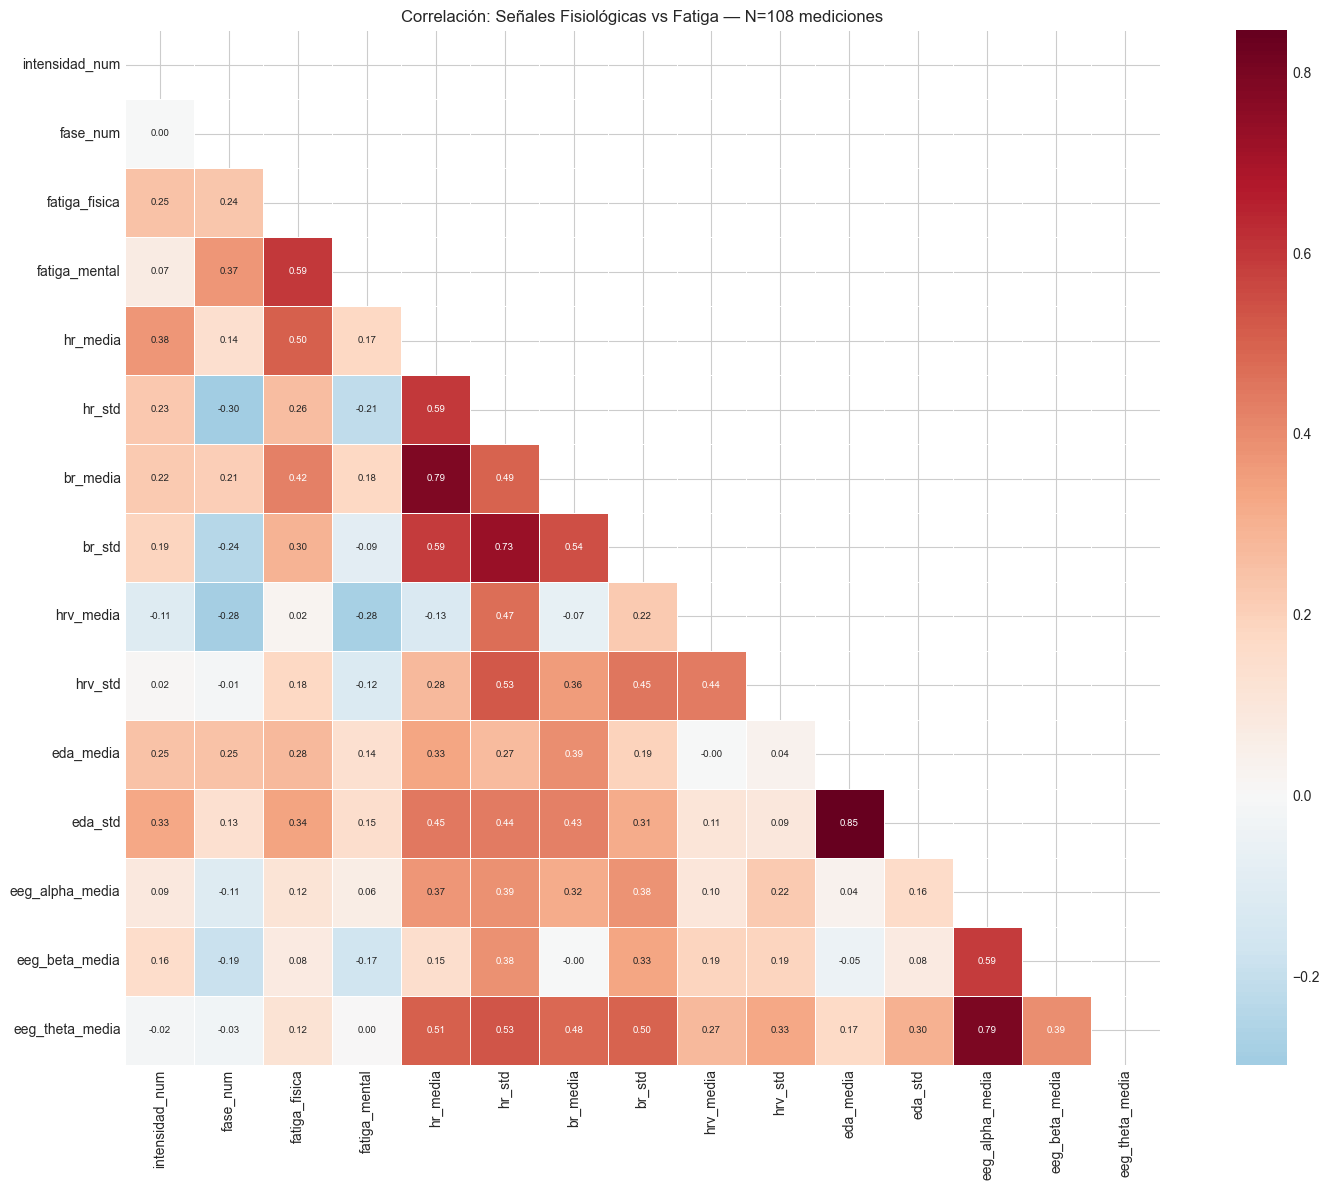


📊 Top correlaciones con Fatiga Mental:
fase_num          0.373
hrv_media        -0.281
hr_std           -0.211
br_media          0.179
hr_media          0.174
eeg_beta_media   -0.170
eda_std           0.149
eda_media         0.138
hrv_std          -0.123
br_std           -0.086


In [16]:
# ============================================================
# CELDA 16 — Matriz de Correlación
# ============================================================
cols_num = df_ml.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(16, 12))
corr = df_ml[cols_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5, mask=mask,
            annot_kws={'size': 7})
plt.title('Correlación: Señales Fisiológicas vs Fatiga — N=108 mediciones', fontsize=12)
plt.tight_layout()
plt.show()

# Top correlaciones con fatiga mental
if 'fatiga_mental' in corr.columns:
    print("\n📊 Top correlaciones con Fatiga Mental:")
    corr_mental = corr['fatiga_mental'].drop(['fatiga_mental','fatiga_fisica'], errors='ignore')
    print(corr_mental.sort_values(key=abs, ascending=False).head(10).round(3).to_string())

In [17]:
# ============================================================
# CELDA 17 — Resumen Final
# ============================================================
print("="*70)
print("📋 RESUMEN FINAL — FATIGUESET COMPLETO")
print("="*70)

print(f"\n📁 Dataset:")
print(f"   Participantes: {len(PARTICIPANTES)} (P01–P12)")
print(f"   Sesiones:      {len(PARTICIPANTES) * 3} (3 por participante)")
print(f"   Mediciones:    {len(PARTICIPANTES) * 3 * 3} (M1, M2, M3 × sesión)")

print(f"\n📋 Protocolo por sesión:")
print(f"   S1 → 3 min baseline fisiológico")
print(f"   M1 → VAS + CRT + N-back   (baseline fatigabilidad)")
print(f"   S2 → 3 min actividad física (5/7/9 km/h según intensidad)")
print(f"   M2 → VAS + CRT + N-back   (post-ejercicio)")
print(f"   S3 → ~15 min task switching (inducción fatiga mental)")
print(f"   M3 → VAS + CRT + N-back   (efecto combinado)")

print(f"\n📊 Señales disponibles:")
print(f"   Chest/Zephyr:  ECG, HR, HRV, BR, Postura, Accel")
print(f"   Wrist/Empatica: HR, EDA, BVP, Temperatura, Accel")
print(f"   Forehead/Muse:  EEG (α,β,δ,γ,θ) + RAW, Accel, Gyro")
print(f"   Ear/eSense:     PPG (verde/IR/rojo), Accel, Gyro (L+R)")
print(f"   Experimental:   N-back, CRT, Task Switch, VAS fatiga")

if df_fatiga is not None:
    print(f"\n📈 Estadísticas de fatiga (VAS 0-100):")
    for fase_num, fase_nombre in sorted(FASES_MEDICION.items()):
        df_f = df_fatiga[df_fatiga['measurementNumber'] == fase_num]
        if not df_f.empty:
            print(f"   {fase_nombre}:")
            print(f"      Física → media={df_f['physicalFatigueScore'].mean():.2f} ± {df_f['physicalFatigueScore'].std():.2f}")
            print(f"      Mental → media={df_f['mentalFatigueScore'].mean():.2f}  ± {df_f['mentalFatigueScore'].std():.2f}")

print(f"\n✅ fatigueset_aggregated_features.csv listo para ML")
print("="*70)

📋 RESUMEN FINAL — FATIGUESET COMPLETO

📁 Dataset:
   Participantes: 12 (P01–P12)
   Sesiones:      36 (3 por participante)
   Mediciones:    108 (M1, M2, M3 × sesión)

📋 Protocolo por sesión:
   S1 → 3 min baseline fisiológico
   M1 → VAS + CRT + N-back   (baseline fatigabilidad)
   S2 → 3 min actividad física (5/7/9 km/h según intensidad)
   M2 → VAS + CRT + N-back   (post-ejercicio)
   S3 → ~15 min task switching (inducción fatiga mental)
   M3 → VAS + CRT + N-back   (efecto combinado)

📊 Señales disponibles:
   Chest/Zephyr:  ECG, HR, HRV, BR, Postura, Accel
   Wrist/Empatica: HR, EDA, BVP, Temperatura, Accel
   Forehead/Muse:  EEG (α,β,δ,γ,θ) + RAW, Accel, Gyro
   Ear/eSense:     PPG (verde/IR/rojo), Accel, Gyro (L+R)
   Experimental:   N-back, CRT, Task Switch, VAS fatiga

📈 Estadísticas de fatiga (VAS 0-100):
   M1_baseline:
      Física → media=14.26 ± 13.83
      Mental → media=18.36  ± 15.49
   M2_post_ejercicio:
      Física → media=31.15 ± 21.60
      Mental → media=24.49  ±

## Notas sobre el pipeline

### Segmentación temporal por fase
Las señales fisiológicas continuas (HR, EDA, EEG...) se segmentan en **tercios** de la sesión como aproximación a las fases M1/M2/M3. Para mayor precisión, usar los timestamps de `exp_markers.csv` para segmentar por los eventos reales del protocolo.

### Dataset ML generado (`fatigueset_aggregated_features.csv`)
- **108 filas** = 12 participantes × 3 sesiones × 3 fases de medición
- **Variables objetivo:** `fatiga_fisica`, `fatiga_mental` (VAS 0-100)
- **Features:** HR, HRV, BR, EDA, EEG(α/β/θ), N-back accuracy/RT, CRT RT
- **Variable de confusión a controlar:** `participante` (efectos inter-sujeto)

### Mapeo de intensidades (`metadata.csv`)
| Participante | Sesión 01 | Sesión 02 | Sesión 03 |
|---|---|---|---|
| 01 | low | medium | high |
| 02 | low | high | medium |
| 03 | medium | high | low |
| 04 | high | medium | low |
| 05 | high | low | medium |
| 06 | medium | low | high |
| 07 | low | medium | high |
| 08 | low | high | medium |
| 09 | medium | high | low |
| 10 | high | medium | low |
| 11 | high | low | medium |
| 12 | medium | low | high |
